# Loan Default Prediction

Predicting whether a loan applicant will **default** using the UCI German Credit
dataset (1,000 historical loans). This notebook walks through:

1. Data loading and target framing
2. Exploratory Data Analysis (EDA)
3. Preprocessing (scaling + encoding)
4. Training and comparing five classifiers
5. Evaluation (ROC-AUC, confusion matrix, key drivers)

**Goal:** flag risky applicants so a lender can avoid losses from defaults.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load the data

The target `credit_risk` is `1` for good credit and `0` for bad credit. Since we want to predict **default**, we define `default = 1` when the credit is bad.

In [2]:
df = pd.read_csv("data/german_credit.csv")
df["default"] = (df["credit_risk"] == 0).astype(int)
df = df.drop(columns=["credit_risk"])
print(df.shape)
df.head()

(1000, 21)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,default
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,4,real estate,67,none,own,2,skilled employee/official,1,yes,yes,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee/official,1,no,yes,1
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,3,real estate,49,none,own,1,unskilled - resident,2,no,yes,0
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,4,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,0
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,4,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  number_credits  

## 2. Exploratory Data Analysis

### 2.1 How many applicants default?

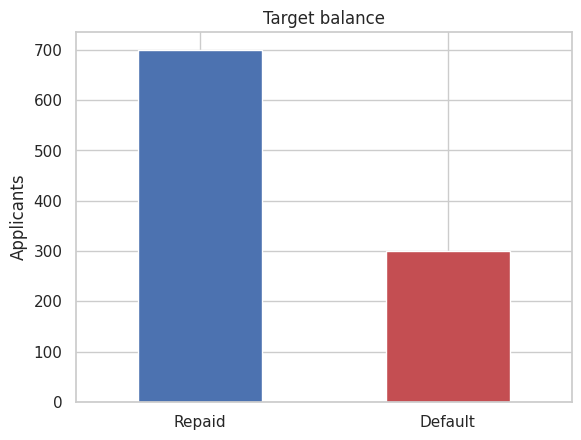

Default rate: 30.0 %


In [4]:
ax = df["default"].value_counts().rename({0: "Repaid", 1: "Default"}).plot(
    kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_title("Target balance"); ax.set_ylabel("Applicants"); ax.set_xlabel("")
plt.xticks(rotation=0); plt.show()
print("Default rate:", round(df["default"].mean() * 100, 1), "%")

About 30% of applicants defaulted — a moderately **imbalanced** problem, so we care about recall and ROC-AUC, not just accuracy.

### 2.2 Numeric features

In [5]:
numeric = ["duration", "amount", "installment_rate", "present_residence",
           "age", "number_credits", "people_liable"]
df[numeric].describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


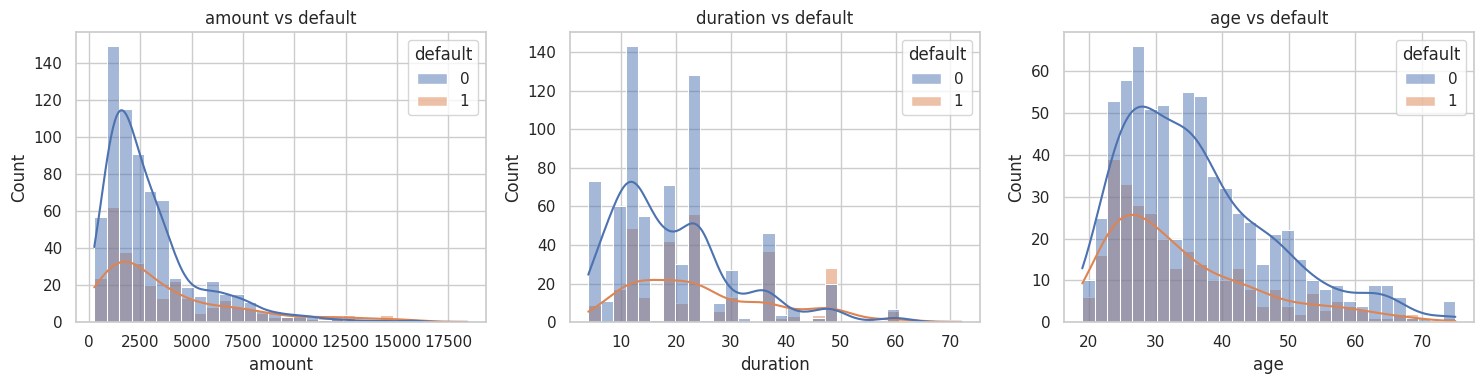

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["amount", "duration", "age"]):
    sns.histplot(data=df, x=col, hue="default", bins=30, kde=True, ax=ax)
    ax.set_title(f"{col} vs default")
plt.tight_layout(); plt.show()

Longer loan durations and larger credit amounts skew toward default, while older applicants tend to repay — all intuitive credit-risk signals.

### 2.3 Default rate by category

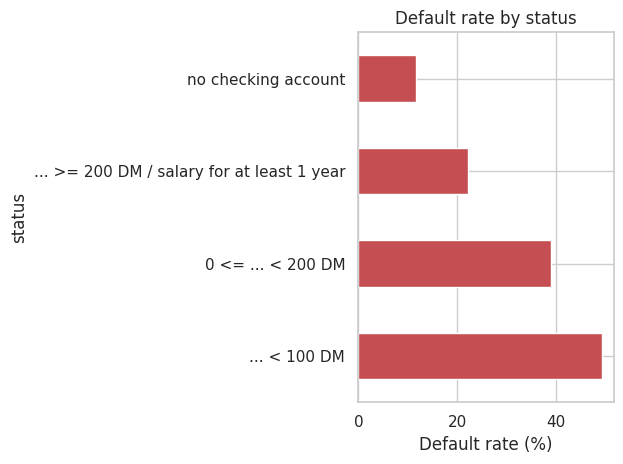

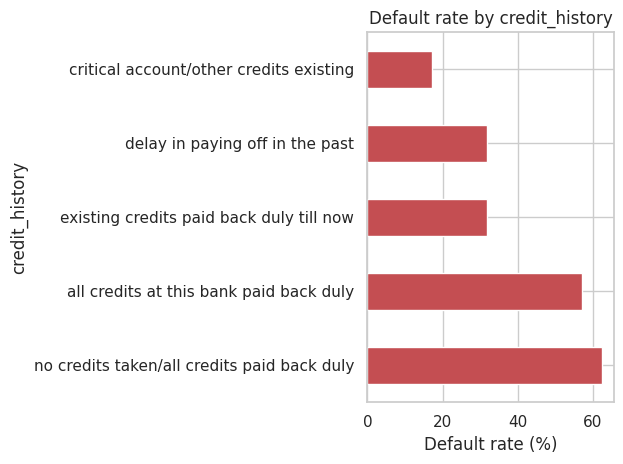

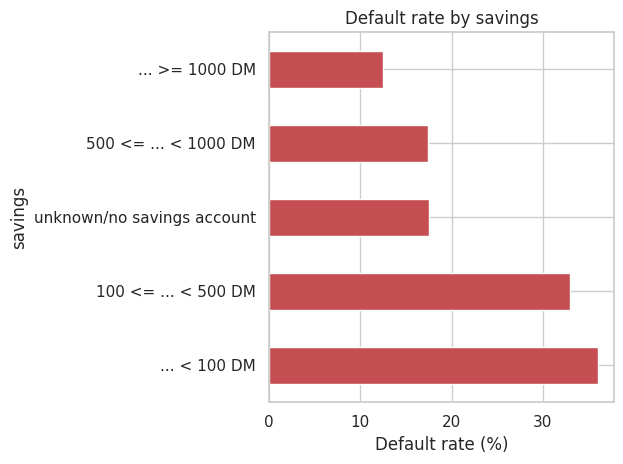

In [7]:
def default_rate_plot(col):
    rate = df.groupby(col)["default"].mean().sort_values(ascending=False) * 100
    ax = rate.plot(kind="barh", color="#C44E52")
    ax.set_title(f"Default rate by {col}"); ax.set_xlabel("Default rate (%)")
    plt.tight_layout(); plt.show()

default_rate_plot("status")        # checking-account status
default_rate_plot("credit_history")
default_rate_plot("savings")

Applicants with **no/low checking balance**, a **critical credit history**, or **little savings** default far more often — these will likely be the strongest predictors.

### 2.4 Numeric correlations

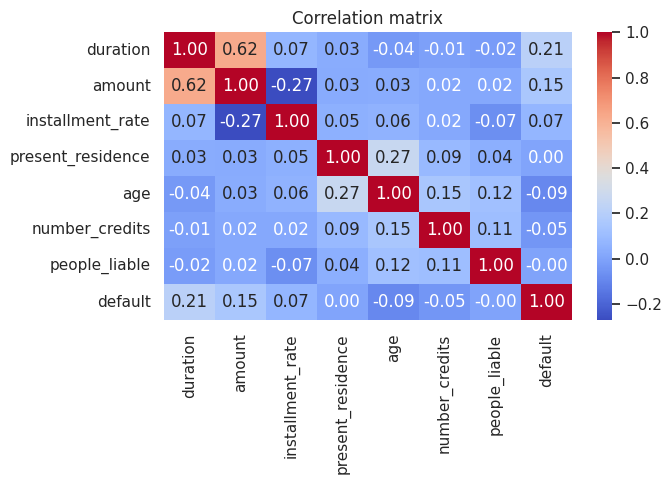

In [8]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric + ["default"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

## 3. Preprocessing

- **Numeric** features are standardized (important for Logistic Regression and KNN).
- **Categorical** features are one-hot encoded.

Both steps live inside a `Pipeline` so the exact same transforms apply to training,
testing, and any future input — no data leakage.

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical = ["status", "credit_history", "purpose", "savings",
               "employment_duration", "personal_status_sex", "other_debtors",
               "property", "other_installment_plans", "housing", "job",
               "telephone", "foreign_worker"]

X = df[numeric + categorical]
y = df["default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (800, 20)  Test: (200, 20)


## 4. Train and compare models

Five classifiers from the course, all with `class_weight="balanced"` where supported
to handle the imbalance. We rank by **ROC-AUC** and also report 5-fold cross-validated AUC.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8,
                                            class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

rows, fitted, roc_data = [], {}, {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)]).fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "ROC_AUC": roc_auc_score(y_test, proba),
                 "CV_ROC_AUC": cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc").mean()})
    fitted[name] = pipe
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, proba))

results = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC
0,Logistic Regression,0.750,0.558,0.800,0.658,0.806,0.785
1,Random Forest,0.755,0.590,0.600,0.595,0.805,0.795
2,Gradient Boosting,0.790,0.680,0.567,0.618,0.792,0.771
3,KNN,0.755,0.667,0.367,0.473,0.747,0.740
4,Decision Tree,0.570,0.377,0.667,0.482,0.599,0.689


### 4.1 ROC curves

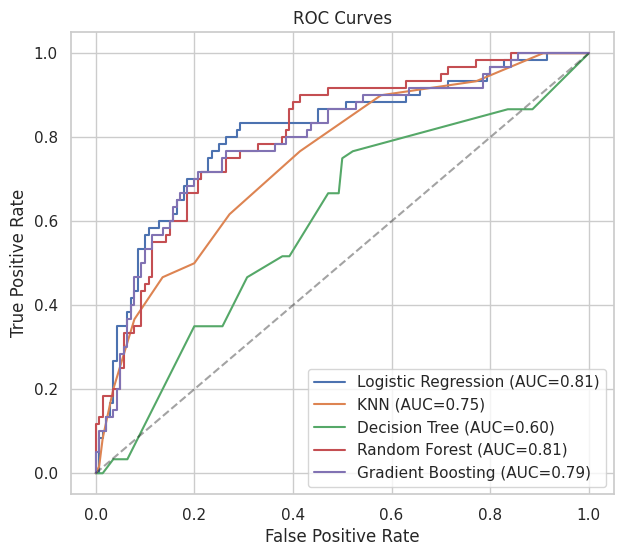

In [11]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(loc="lower right"); plt.show()

## 5. Best model — evaluation

Best model: Logistic Regression


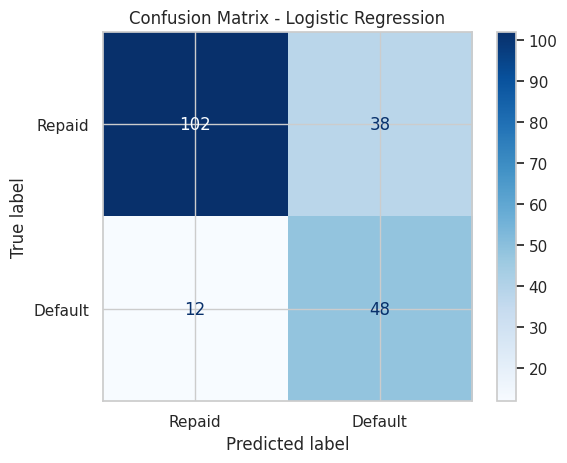

In [12]:
best_name = results.iloc[0]["Model"]
best = fitted[best_name]
print("Best model:", best_name)

cm = confusion_matrix(y_test, best.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["Repaid", "Default"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}"); plt.show()

### 5.1 What drives the prediction?

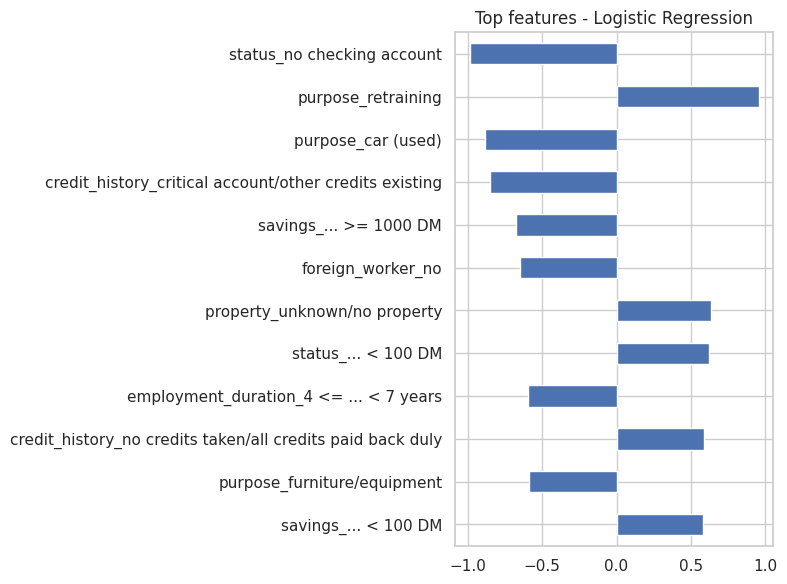

In [13]:
# Pull feature names out of the fitted preprocessor
ohe = best.named_steps["prep"].named_transformers_["cat"]
feat_names = numeric + list(ohe.get_feature_names_out(categorical))
clf = best.named_steps["clf"]

if hasattr(clf, "coef_"):
    imp = pd.Series(clf.coef_[0], index=feat_names)
elif hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=feat_names)

top = imp.reindex(imp.abs().sort_values(ascending=False).index).head(12)
top[::-1].plot(kind="barh", figsize=(8, 6), color="#4C72B0")
plt.title(f"Top features - {best_name}"); plt.tight_layout(); plt.show()

## 6. Conclusion

- Best model reaches **~0.80 ROC-AUC** at predicting loan default.
- The strongest signals match financial intuition: **checking-account status,
  credit history, loan duration, savings, and credit amount**.
- Because defaults are costly, the models use balanced class weights to prioritize
  **recall** (catching real defaulters) over raw accuracy.

**Next steps:** threshold tuning for a target precision/recall, hyperparameter search,
and trying XGBoost. The best pipeline is exported in `train.py` and served by the
Streamlit app in `app.py`.
